# Technical benchmark: provider-calibrated total reach and demographic allocation

This notebook evaluates a model-provider architecture in which two models run for every report:

1. A **demographic-agnostic total-reach model** uses aggregate Reference-ID and campaign inputs to estimate calibrated union reach.
2. The existing **VID demographic model** produces age, gender, and geography estimates. A provider-supplied adjustment makes those estimates agree with the calibrated total.

The measurement system runs both models. It does not fit a new calibration model for each report and does not need access to the provider's panel or internal model coefficients.

The benchmark separates four questions:

- Does a panel-trained total model improve union reach?
- Does campaign objective and audience strategy add information beyond Reference-ID counts?
- Is proportional demographic scaling sufficient, or does a panel-learned adjustment help?
- Does the architecture preserve basic bounds and cross-report consistency?

In [1]:
from pathlib import Path
import csv
import json
import sys

import numpy as np
from IPython.display import Image, Markdown, display


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run from the repository root or notebooks/.")


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, separator, *body])


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "provider_model_final"

RUN_BENCHMARK = False
if RUN_BENCHMARK:
    from reference_calibration.provider_benchmark import run_provider_benchmark
    run_provider_benchmark(OUTPUT_DIR, profile="full")

summary = json.loads((OUTPUT_DIR / "provider_summary.json").read_text())
with (OUTPUT_DIR / "provider_metrics.csv").open() as stream:
    metrics = list(csv.DictReader(stream))
methods = {item["name"]: item for item in summary["methods"]}

print("Project: repository root")
print(f"Benchmark outputs: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Detailed metric rows: {len(metrics):,}")

Project: repository root
Benchmark outputs: outputs/provider_model_final
Detailed metric rows: 26,325


## 1. Runtime data flow

For a requested campaign, week set, and EDP set, the measurement system supplies the model provider's approved workload with:

- each EDP's reach;
- the aggregate Reference-ID overlap pattern, including pairwise and available higher-order counts;
- the participating EDPs;
- campaign objective and audience-strategy summaries; and
- campaign scale and reporting-window information.

The total model returns one calibrated union-reach estimate (T). Separately, the VID demographic model returns an initial vector (v_1,ldots,v_D). The provider-packaged demographic method returns:

\[
(R_1,\ldots,R_D)=g(T,v_1,\ldots,v_D,\text{report context}).
\]

No Reference ID is assigned an age, gender, or geography, and no VID-to-Reference-ID crosswalk is constructed.

## 2. Synthetic panel and holdout design

The population contains ten EDPs, thirteen weeks, and eighteen mutually exclusive age × gender × geography cells. The harness creates a true demographic label and a stable but imperfect VID demographic label for each synthetic person. VID labeling is somewhat more accurate for people who are easier to link, creating realistic interaction between audience selection, matchability, and demographic error.

The panel-training campaigns span all thirteen campaign scenarios rather than only broad reach. Every snapshot and report shape from one campaign remains in the same split. Separate campaign seeds are used for:

- provider-model fitting;
- whole-campaign panel holdouts; and
- independent scenario evaluation.

This is deliberately favorable to a model provider with a diverse panel. It tests whether moving calibration upstream can work when the provider has representative examples of the intended campaign types. It does not establish that a real panel has this coverage.

In [2]:
design_rows = [
    {"item": "Panel-training campaigns", "value": summary["panel_train_campaigns"]},
    {"item": "Whole-campaign panel holdouts", "value": summary["panel_holdout_campaigns"]},
    {"item": "Independent evaluation campaigns", "value": summary["evaluation_campaigns"]},
    {"item": "Training report observations", "value": summary["training_observations"]},
    {"item": "Demographic cells", "value": summary["demographic_cells"]},
    {"item": "EDP counts tested", "value": "2, 5, and 10"},
]
display(Markdown(markdown_table(design_rows, [("item", "Design item"), ("value", "Value")])))

| Design item | Value |
|---|---|
| Panel-training campaigns | 39 |
| Whole-campaign panel holdouts | 26 |
| Independent evaluation campaigns | 39 |
| Training report observations | 234 |
| Demographic cells | 18 |
| EDP counts tested | 2, 5, and 10 |

## 3. Illustrative provider total model

The provider model in this notebook is an implementation example, not a required production model family. It predicts the logarithmic correction to the existing VID total:

\[
\widehat T = T_{VID}\exp(f(x)).
\]

The result is clipped to the ordinary logical range: at least the largest individual EDP reach and no more than the summed EDP reaches or population.

The observable feature vector includes:

- individual EDP presence and reach;
- pairwise Reference-ID overlap relative to the smaller EDP and to the VID pair estimate;
- summary statistics for pairwise, three-way, and higher-order Reference-ID signals;
- report size and the VID total; and, in the context-aware version,
- objective and audience-strategy proportions, both unweighted and reach-weighted.

A regularized radial-basis model is fitted against panel-truth total reach. The context-free and context-aware versions use the same fitting process, allowing the value of campaign metadata to be measured directly.

In [3]:
parameter_rows = [
    {
        "model": "Provider total: Reference-ID inputs only",
        "parameters": summary["provider_models"]["reference_only_parameter_count"],
    },
    {
        "model": "Provider total: Reference ID + campaign context",
        "parameters": summary["provider_models"]["context_parameter_count"],
    },
    {
        "model": "Contextual demographic adjustment",
        "parameters": summary["provider_models"]["contextual_demographic_parameter_count"],
    },
]
display(Markdown(markdown_table(parameter_rows, [("model", "Model"), ("parameters", "Stored parameters")])) )

| Model | Stored parameters |
|---|---|
| Provider total: Reference-ID inputs only | 32568 |
| Provider total: Reference ID + campaign context | 41064 |
| Contextual demographic adjustment | 1116 |

## 4. Total-reach methods compared

The benchmark also fits two measurement-layer approaches on representative reach campaigns in the same synthetic world:

- direct pair calibration followed by maximum-entropy higher-order inference; and
- two-group mixture pair calibration followed by the same inference step.

This produces an apples-to-apples comparison with the provider models because every method is evaluated on the same campaigns and report requests.

| Method | Evaluation mean | Panel holdout mean | Evaluation p90 | 2 EDPs | 5 EDPs | 10 EDPs |
|---|---|---|---|---|---|---|
| Existing VID | 39.72% | 39.79% | 91.64% | 12.46% | 41.33% | 65.38% |
| Direct pair inference + proportional demos | 11.80% | 11.61% | 25.40% | 2.86% | 10.79% | 21.75% |
| Mixture pair inference + proportional demos | 9.69% | 9.74% | 22.48% | 3.59% | 11.02% | 14.47% |
| Provider total, Reference-ID inputs only + proportional demos | 5.85% | 6.02% | 17.01% | 2.56% | 5.20% | 9.79% |
| Provider total with context + proportional demos | 3.19% | 3.36% | 9.63% | 1.74% | 1.90% | 5.94% |

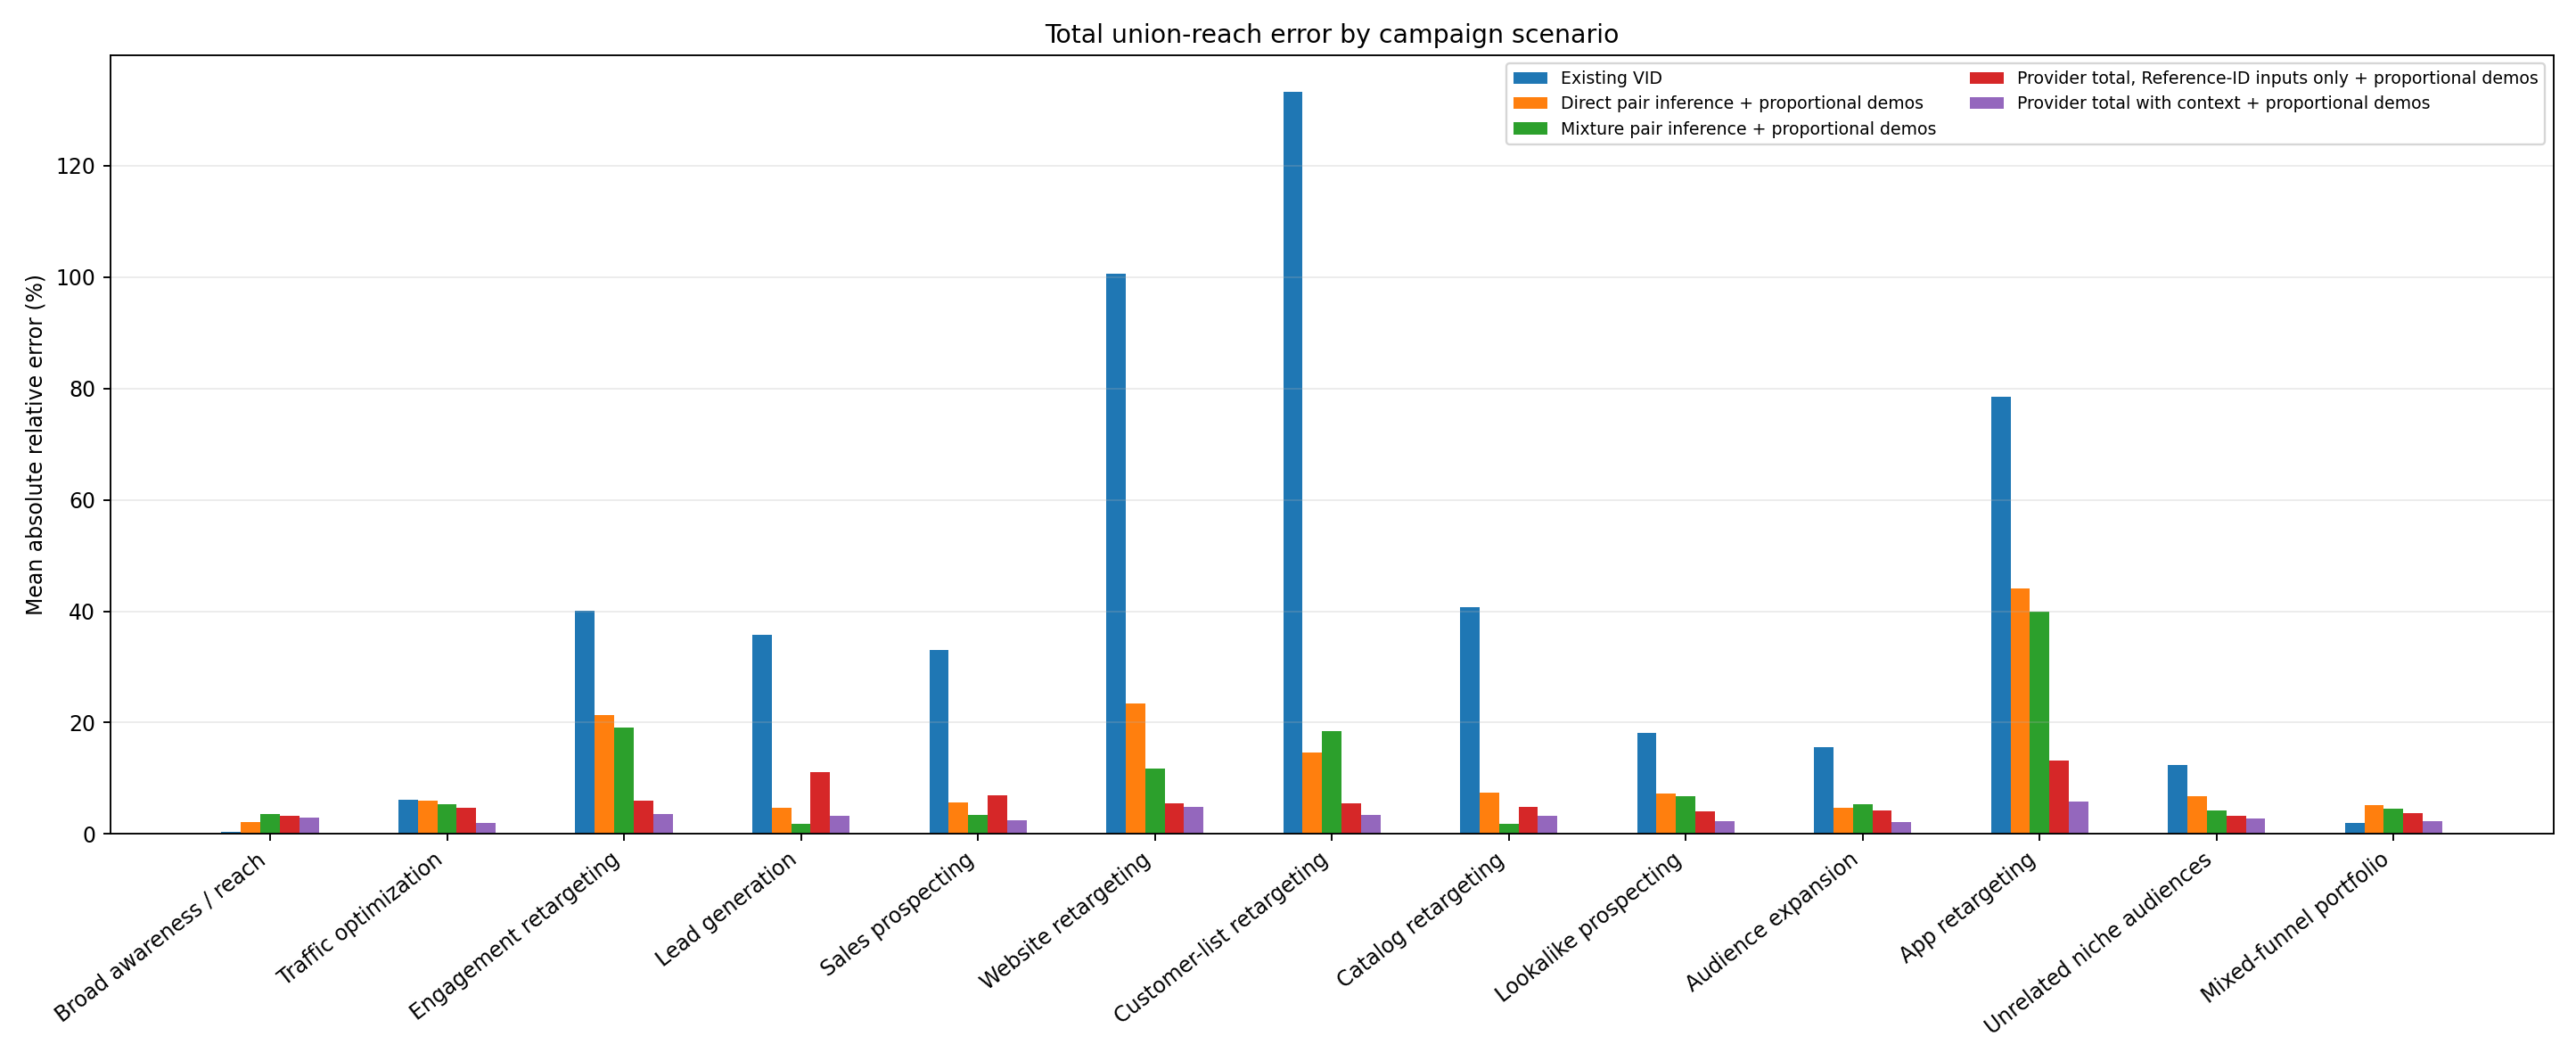

In [4]:
TOTAL_METHODS = [
    "existing_vid",
    "direct_pair_proportional",
    "mixture_pair_proportional",
    "provider_reference_proportional",
    "provider_context_proportional",
]
rows = []
for name in TOTAL_METHODS:
    item = methods[name]
    holdout = next(value for value in summary["holdout_methods"] if value["name"] == name)
    rows.append({
        "method": item["label"],
        "evaluation": f"{item['total_error']['mean']:.2%}",
        "holdout": f"{holdout['total_error']['mean']:.2%}",
        "p90": f"{item['total_error']['p90']:.2%}",
        "two": f"{item['total_error_by_edp_count']['2']['mean']:.2%}",
        "five": f"{item['total_error_by_edp_count']['5']['mean']:.2%}",
        "ten": f"{item['total_error_by_edp_count']['10']['mean']:.2%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("method", "Method"),
        ("evaluation", "Evaluation mean"),
        ("holdout", "Panel holdout mean"),
        ("p90", "Evaluation p90"),
        ("two", "2 EDPs"),
        ("five", "5 EDPs"),
        ("ten", "10 EDPs"),
    ],
)))
display(Image(filename=str(OUTPUT_DIR / "provider_total_error_by_scenario.png")))

## 5. Demographic allocation methods

The benchmark tests three provider choices:

### Proportional scaling

\[
R_d=T\frac{v_d}{\sum_k v_k}.
\]

This fixes the total while preserving the VID demographic mix.

### Fixed panel adjustment

The provider learns one additive share correction for each demographic cell from panel campaigns. The correction is normalized so the resulting shares sum to one.

### Contextual panel adjustment

The provider learns how the VID share error changes with objective, audience strategy, participating EDPs, campaign scale, and the starting VID distribution. The model predicts changes to demographic shares rather than another total, preventing the two model components from competing over total reach.

The final shares are projected onto the nonnegative demographic simplex and multiplied by (T). Population caps are enforced. The measurement system sees only the packaged adjustment function.

| Method | Total-reach error | Combined demographic reach error | Demographic distribution error |
|---|---|---|---|
| Existing VID | 39.72% | 41.72% | 5.61% |
| Provider total with context + proportional demos | 3.19% | 12.52% | 5.61% |
| Provider total + fixed panel demo adjustment | 3.19% | 11.88% | 5.35% |
| Provider total + contextual panel demo adjustment | 3.19% | 6.32% | 2.51% |
| Oracle total + proportional demos | 0.00% | 11.22% | 5.61% |
| Oracle total + contextual panel demos | 0.00% | 5.00% | 2.50% |

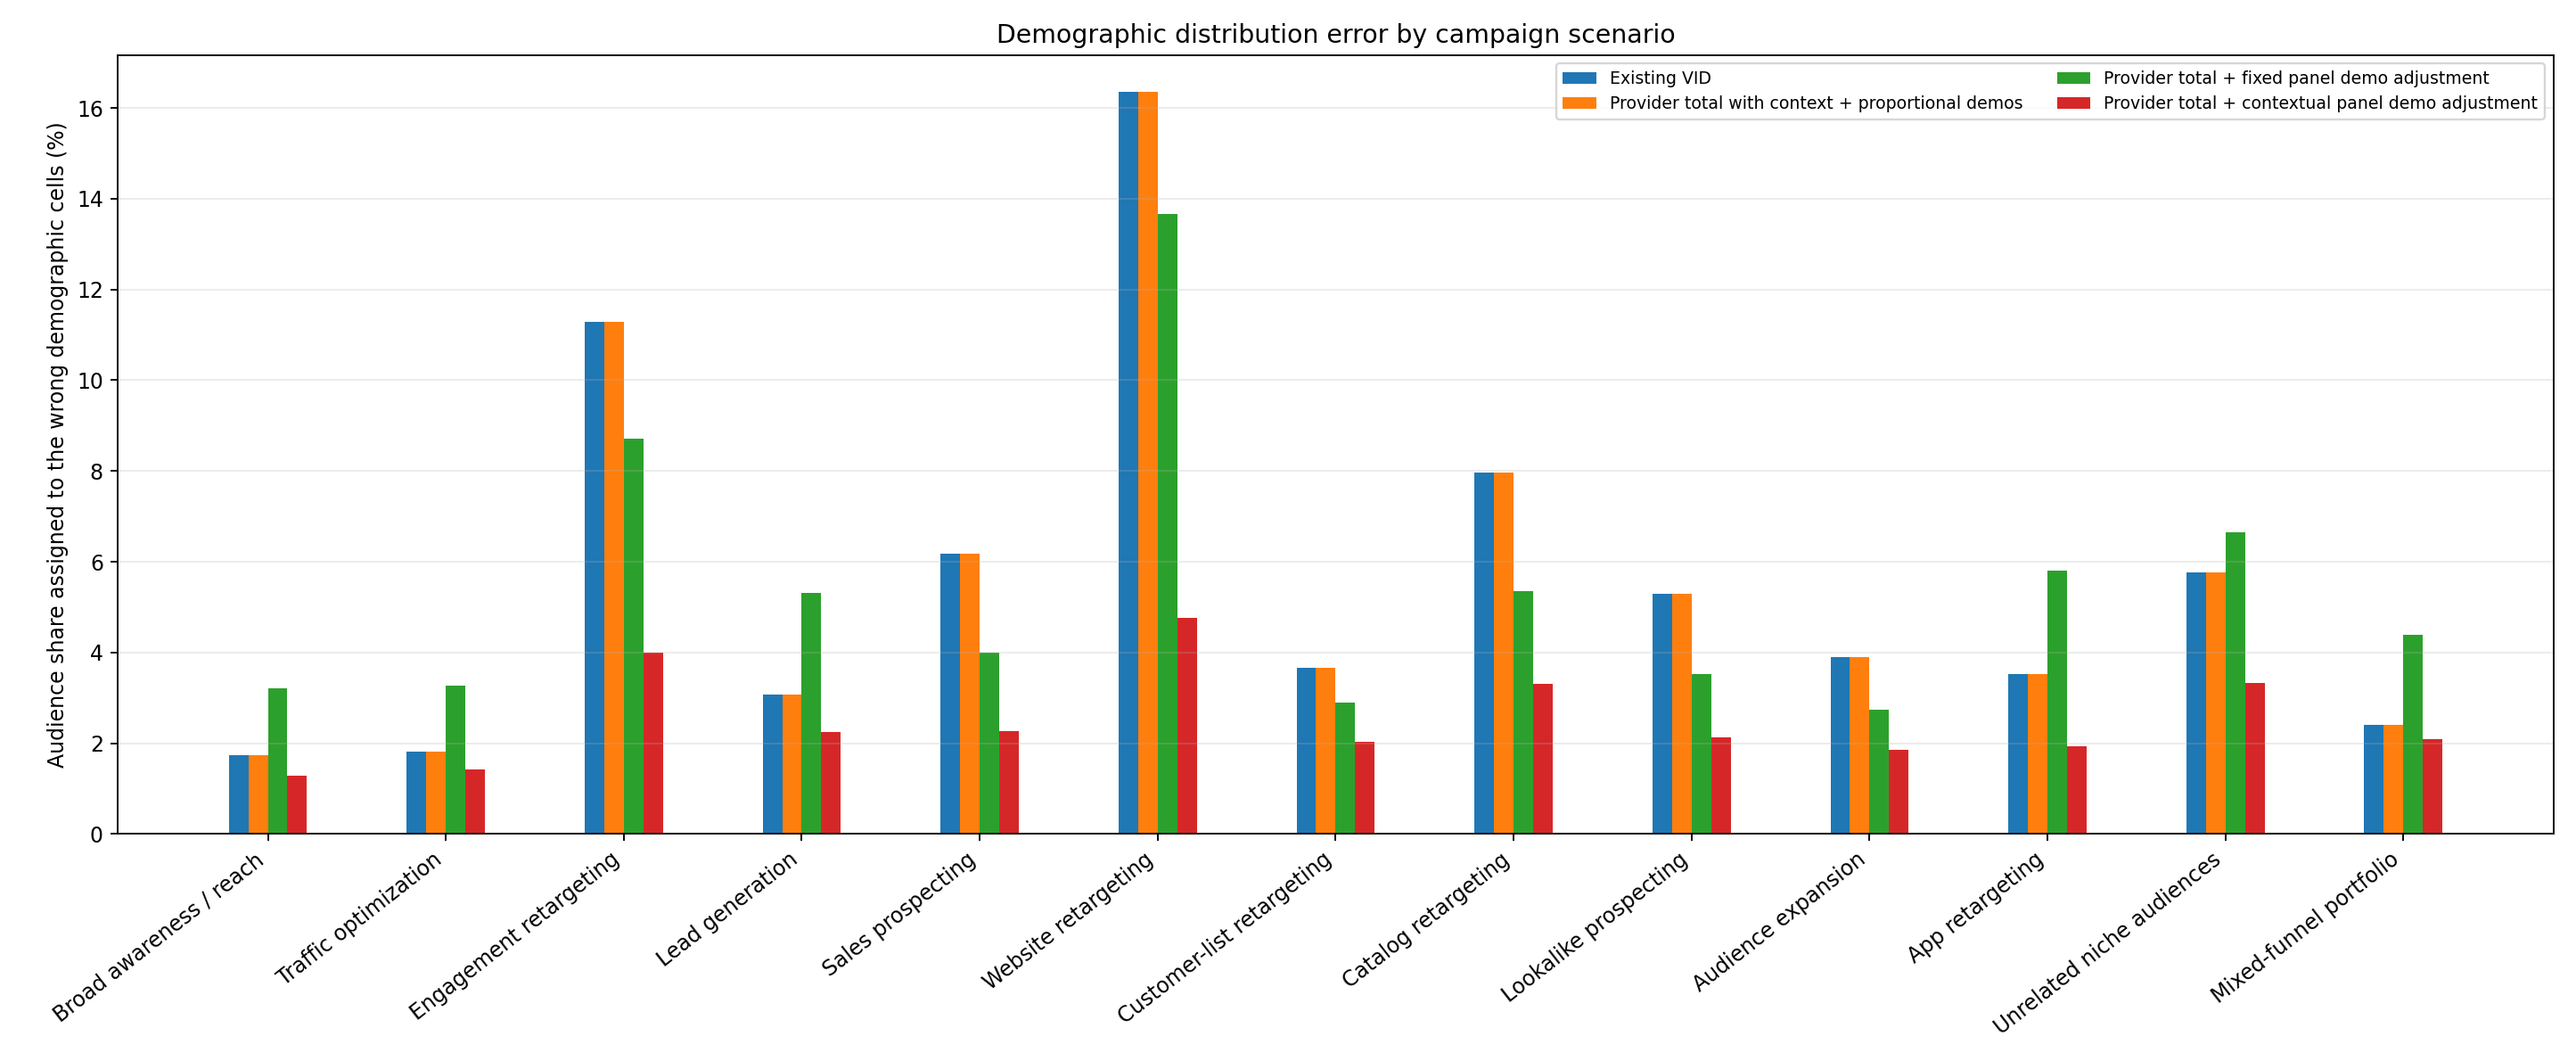

In [5]:
DEMO_METHODS = [
    "existing_vid",
    "provider_context_proportional",
    "provider_context_fixed_demo",
    "provider_context_learned_demo",
    "oracle_total_proportional",
    "oracle_total_learned_demo",
]
rows = []
for name in DEMO_METHODS:
    item = methods[name]
    rows.append({
        "method": item["label"],
        "total": f"{item['total_error']['mean']:.2%}",
        "demo_reach": f"{item['demographic_reach_error']['mean']:.2%}",
        "demo_distribution": f"{item['demographic_distribution_error']['mean']:.2%}",
    })
display(Markdown(markdown_table(
    rows,
    [
        ("method", "Method"),
        ("total", "Total-reach error"),
        ("demo_reach", "Combined demographic reach error"),
        ("demo_distribution", "Demographic distribution error"),
    ],
)))
display(Image(filename=str(OUTPUT_DIR / "provider_demographic_error_by_scenario.png")))

## 6. Interpreting the demographic metrics

Combined demographic reach error includes both total-reach error and incorrect allocation among demographic cells. Demographic distribution error first normalizes both vectors to shares and then measures how much audience share must move between cells to match truth.

The oracle-total rows are important. If proportional scaling still has material error with perfect total reach, the remaining problem is demographic allocation rather than deduplication. The difference between oracle proportional and oracle learned allocation measures the incremental value of the provider's panel-based demographic adjustment.

## 7. Output validity

Every demographic method is checked for:

- negative values;
- demographic values above their population;
- failure to add exactly to the corresponding total estimate; and
- behavior for 2-, 5-, and 10-EDP reports.

In [6]:
validity_rows = []
for name in DEMO_METHODS:
    sum_errors = [
        float(row["value"])
        for row in metrics
        if row["split"] == "evaluation"
        and row["method"] == name
        and row["category"] == "demographic_sum_error"
    ]
    population_errors = [
        float(row["value"])
        for row in metrics
        if row["split"] == "evaluation"
        and row["method"] == name
        and row["category"] == "demographic_population_violation"
    ]
    validity_rows.append({
        "method": methods[name]["label"],
        "max_sum_error": f"{max(sum_errors, default=0.0):.3%}",
        "max_population_violation": f"{max(population_errors, default=0.0):.3%}",
    })
display(Markdown(markdown_table(
    validity_rows,
    [
        ("method", "Method"),
        ("max_sum_error", "Largest total mismatch"),
        ("max_population_violation", "Largest population violation"),
    ],
)))

| Method | Largest total mismatch | Largest population violation |
|---|---|---|
| Existing VID | 0.000% | 0.000% |
| Provider total with context + proportional demos | 0.000% | 0.000% |
| Provider total + fixed panel demo adjustment | 0.000% | 0.000% |
| Provider total + contextual panel demo adjustment | 0.000% | 0.000% |
| Oracle total + proportional demos | 0.000% | 0.000% |
| Oracle total + contextual panel demos | 0.000% | 0.000% |

## 8. Cross-report consistency

The provider total model is a deterministic function of the requested report, but separate predictions for nested reports are not mathematically guaranteed to be monotone. The benchmark checks:

- weeks 1–3 versus weeks 1–12;
- weeks 1–12 versus the full flight;
- two EDPs versus five EDPs; and
- five EDPs versus ten EDPs.

The stored-result reconciliation mechanism remains useful when published reports must never contradict earlier results.

In [7]:
consistency_rows = []
for name in TOTAL_METHODS:
    result = summary["consistency"]["evaluation"][name]
    consistency_rows.append({
        "method": methods[name]["label"],
        "checks": result["checks"],
        "violations": result["violations"],
        "maximum": f"{result['maximum'] / 1_000_000:.3f}M",
    })
display(Markdown(markdown_table(
    consistency_rows,
    [
        ("method", "Method"),
        ("checks", "Checks"),
        ("violations", "Raw violations"),
        ("maximum", "Largest violation"),
    ],
)))

| Method | Checks | Raw violations | Largest violation |
|---|---|---|---|
| Existing VID | 156 | 0 | 0.000M |
| Direct pair inference + proportional demos | 156 | 2 | 0.994M |
| Mixture pair inference + proportional demos | 156 | 3 | 0.391M |
| Provider total, Reference-ID inputs only + proportional demos | 156 | 10 | 2.213M |
| Provider total with context + proportional demos | 156 | 10 | 2.723M |

## 9. Conclusions and decision rule

The synthetic result favors the provider-model architecture in this test:

1. A panel-trained total model performs better than the existing VID baseline and the two strongest measurement-layer calibration comparators.
2. Objective and audience-strategy inputs improve the provider total model relative to the same model using Reference-ID inputs alone.
3. Proportional scaling is a valid, simple demographic baseline, but it leaves demographic error even when total reach is known perfectly.
4. The contextual panel adjustment reduces demographic error in both whole-campaign holdouts and independent evaluation campaigns.
5. The provider model still creates occasional raw cross-report inconsistencies, so the existing reconciliation layer remains relevant.

The exact radial-basis total model and linear demographic adjustment used here are examples, not prescribed production choices. The model provider should be free to select another total-reach or demographic-adjustment method, provided the packaged model accepts the agreed inputs, returns bounded outputs, and beats simpler alternatives on whole-campaign panel holdouts.

The next validation should reproduce this comparison with real panel campaigns, including broad awareness, CRM, website retargeting, app activity, lead, sales, lookalike, and mixed-objective reports. The provider should compare at least:

- total model without campaign context;
- total model with campaign context;
- proportional demographic scaling; and
- its proposed panel-learned demographic adjustment.